In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
file = r"../Dataset/Cleaned_Academic_Probation_Project.xlsx"

df = pd.read_excel(
    file,
    sheet_name="Master_Education_Data (2)"
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (10000, 16)


,Student_ID,Student_Name,Gender,Department,Semester,Attendance_Percentage,GPA,Assignment_Score,Quiz_Score,Internal_Marks,LMS_Login_Count,Study_Hours_Per_Week,Backlog_Count,Last_Login_Date,Admission_Year,Probation_Status
0,S0001,Ajay Das,Male,AI&DS,8,57.0,6.67,76,38,95,41,35,2,2025-07-28 00:00:00,2023,Yes
1,S0002,Pavithra Murthy,Female,IT,1,83.0,7.08,91,62,41,234,29,1,2026-05-27 00:00:00,2022,No
2,S0003,Sandhya Das,Female,EEE,5,72.0,6.20,83,87,55,3,3,2,2026-04-19 00:00:00,2026,No
3,S0004,Rekha Balakrishnan,Female,AI&DS,3,67.0,6.08,55,91,89,3,17,2,2026-02-03 00:00:00,2024,No
4,S0005,Balaji Gupta,Male,EEE,5,44.0,2.31,84,62,80,166,2,3,2026-01-03 00:00:00,2024,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Student_Name           10000 non-null  object 
 2   Gender                 10000 non-null  object 
 3   Department             10000 non-null  object 
 4   Semester               10000 non-null  int64  
 5   Attendance_Percentage  10000 non-null  float64
 6   GPA                    10000 non-null  float64
 7   Assignment_Score       10000 non-null  int64  
 8   Quiz_Score             10000 non-null  int64  
 9   Internal_Marks         10000 non-null  int64  
 10  LMS_Login_Count        10000 non-null  int64  
 11  Study_Hours_Per_Week   10000 non-null  int64  
 12  Backlog_Count          10000 non-null  int64  
 13  Last_Login_Date        10000 non-null  object 
 14  Admission_Year         10000 non-null  int64  
 15  Pro

In [4]:
df.describe()

,Semester,Attendance_Percentage,GPA,Assignment_Score,Quiz_Score,Internal_Marks,LMS_Login_Count,Study_Hours_Per_Week,Backlog_Count,Admission_Year
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,4.490200,69.989715,5.707241,69.581300,69.733300,69.646200,80.246300,20.171400,2.86200,2023.549300
std,2.298354,17.348855,2.400161,17.802935,17.784094,17.704982,49.429726,11.425107,2.01424,1.171711
min,1.000000,40.000000,1.500000,35.000000,35.000000,35.000000,1.000000,1.000000,0.00000,2022.000000
25%,2.000000,54.817500,3.700000,54.000000,54.000000,55.000000,39.000000,10.000000,1.00000,2022.000000
50%,4.000000,70.000000,5.690000,70.000000,70.000000,70.000000,78.000000,20.000000,3.00000,2024.000000
75%,6.000000,85.000000,7.730000,85.000000,85.000000,85.000000,118.000000,30.000000,5.00000,2025.000000
max,8.000000,100.000000,10.000000,100.000000,100.000000,100.000000,250.000000,40.000000,6.00000,2026.000000


In [14]:
# Attendance Outlier Detection using IQR

Q1 = df['Attendance_Percentage'].quantile(0.25)
Q3 = df['Attendance_Percentage'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

attendance_outliers = df[
    (df['Attendance_Percentage'] < lower_bound) |
    (df['Attendance_Percentage'] > upper_bound)
]

print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")
print(f"Total Attendance Outliers : {len(attendance_outliers)}")

Lower Bound : 9.54
Upper Bound : 130.27
Total Attendance Outliers : 0


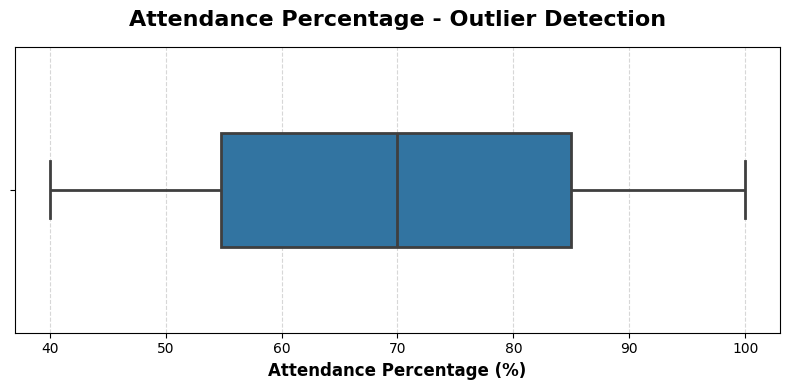

In [19]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["Attendance_Percentage"],
    linewidth=2,
    width=0.4,
    fliersize=5
)

plt.title(
    "Attendance Percentage - Outlier Detection",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Attendance Percentage (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Attendance_Outlier_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
# GPA Outlier Detection using IQR

Q1 = df['GPA'].quantile(0.25)
Q3 = df['GPA'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

gpa_outliers = df[
    (df['GPA'] < lower_bound) |
    (df['GPA'] > upper_bound)
]

print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")
print(f"Total GPA Outliers : {len(gpa_outliers)}")

Lower Bound : -2.34
Upper Bound : 13.78
Total GPA Outliers : 0


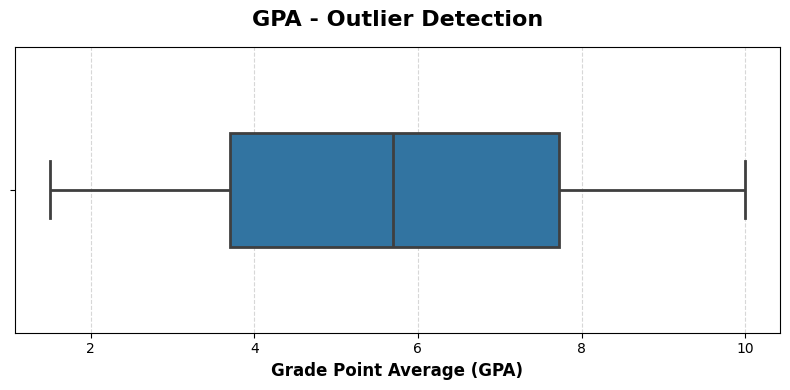

In [18]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["GPA"],
    linewidth=2,
    width=0.4,
    fliersize=5
)

plt.title(
    "GPA - Outlier Detection",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Grade Point Average (GPA)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Output_Charts/GPA_Outlier_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
def assign_risk(row):

    if (
        row['Attendance_Percentage'] < 50 or
        row['GPA'] < 5 or
        row['Backlog_Count'] > 3
    ):
        return "Critical Risk"

    elif (
        row['Attendance_Percentage'] < 75 or
        row['GPA'] < 6.5
    ):
        return "At Risk"

    else:
        return "Normal"

df["Risk_Level"] = df.apply(assign_risk, axis=1)

df[["Attendance_Percentage","GPA","Backlog_Count","Risk_Level"]].head()

,Attendance_Percentage,GPA,Backlog_Count,Risk_Level
0,57.0,6.67,2,At Risk
1,83.0,7.08,1,Normal
2,72.0,6.20,2,At Risk
3,67.0,6.08,2,At Risk
4,44.0,2.31,3,Critical Risk


In [21]:
risk_counts = df["Risk_Level"].value_counts()

print(risk_counts)

Risk_Level
Critical Risk    6847
At Risk          1960
Normal           1193
Name: count, dtype: int64


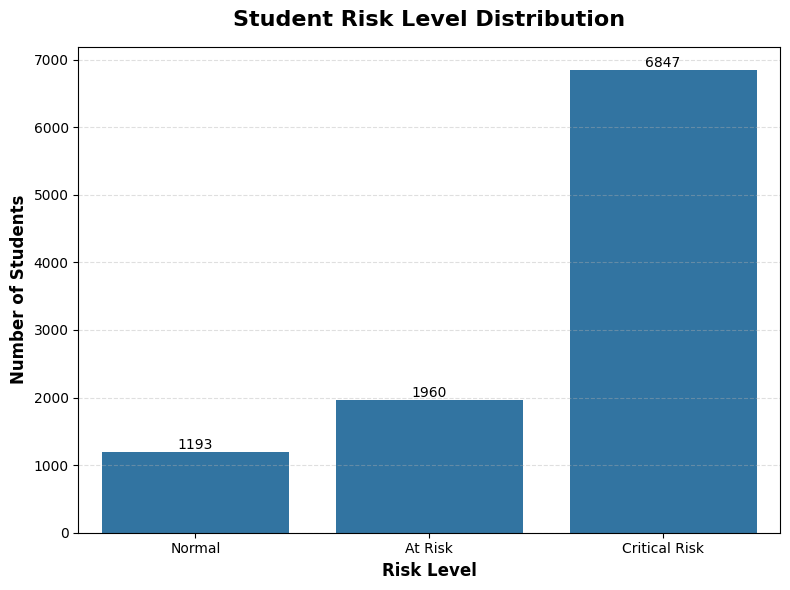

In [22]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x="Risk_Level",
    order=["Normal","At Risk","Critical Risk"]
)

plt.title(
    "Student Risk Level Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Risk Level",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Students",
    fontsize=12,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Risk_Level_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Feature Selection
X = df[
    [
        "Attendance_Percentage",
        "GPA",
        "Assignment_Score",
        "Quiz_Score",
        "Internal_Marks",
        "LMS_Login_Count",
        "Study_Hours_Per_Week",
        "Backlog_Count"
    ]
]

# Target Variable
y = df["Probation_Status"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (10000, 8)
Target Shape : (10000,)


In [24]:
y = y.map({
    "Yes":1,
    "No":0
})

print(y.value_counts())

Probation_Status
1    7881
0    2119
Name: count, dtype: int64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (8000, 8)
Testing Data : (2000, 8)


In [26]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM Model Trained Successfully!")

SVM Model Trained Successfully!


In [28]:
y_pred = svm_model.predict(X_test_scaled)

In [29]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Model Accuracy : {accuracy*100:.2f}%")

Model Accuracy : 97.55%


In [30]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       424
           1       0.98      0.98      0.98      1576

    accuracy                           0.98      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.98      0.98      0.98      2000



<Figure size 600x500 with 0 Axes>

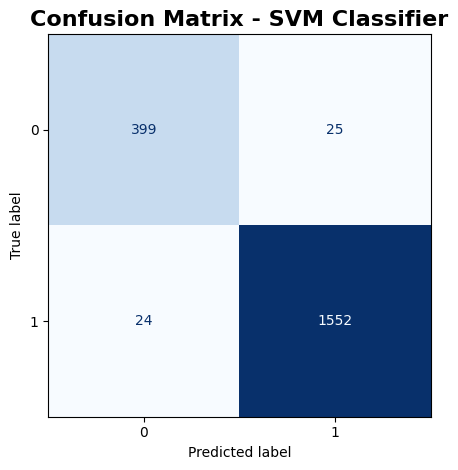

In [31]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Confusion Matrix - SVM Classifier",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Output_Charts/Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()